In [2]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# ============================================================
# LOAD ZOO DATASET
# ============================================================
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/zoo/zoo.data"

columns = [
    "animal_name", "hair", "feathers", "eggs", "milk", "airborne", "aquatic",
    "predator", "toothed", "backbone", "breathes", "venomous", "fins",
    "legs", "tail", "domestic", "catsize", "class_type"
]

data = pd.read_csv(url, header=None, names=columns)
data = data.drop("animal_name", axis=1)

X = data.drop("class_type", axis=1)
y = data["class_type"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# ============================================================
# PART 1: DECISION TREE USING SCIKIT-LEARN
# ============================================================

print("\n==============================")
print("SKLEARN DECISION TREE RESULTS")
print("==============================\n")

clf = DecisionTreeClassifier(criterion="gini", random_state=42)
clf.fit(X_train, y_train)

y_pred_sklearn = clf.predict(X_test)

cm_sklearn = confusion_matrix(y_test, y_pred_sklearn)
print("Confusion Matrix:\n")
print(cm_sklearn)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_sklearn))

# ============================================================
# PART 2: DECISION TREE FROM SCRATCH
# ============================================================

print("\n==============================")
print("CUSTOM DECISION TREE RESULTS")
print("==============================\n")

class DecisionTreeCustom:
    def __init__(self, max_depth=10):
        self.max_depth = max_depth
        self.tree = None

    def gini(self, y):
        counts = Counter(y)
        impurity = 1
        for label in counts:
            prob = counts[label] / len(y)
            impurity -= prob ** 2
        return impurity

    def best_split(self, X, y):
        best_gini = float("inf")
        best_feature = None
        best_value = None

        X = np.array(X)
        y = np.array(y)

        for feature in range(X.shape[1]):
            values = np.unique(X[:, feature])

            for val in values:
                left = y[X[:, feature] <= val]
                right = y[X[:, feature] > val]

                if len(left) == 0 or len(right) == 0:
                    continue

                gini = (len(left)/len(y))*self.gini(left) + \
                       (len(right)/len(y))*self.gini(right)

                if gini < best_gini:
                    best_gini = gini
                    best_feature = feature
                    best_value = val

        return best_feature, best_value

    def build_tree(self, X, y, depth):
        if len(set(y)) == 1 or depth >= self.max_depth:
            return Counter(y).most_common(1)[0][0]

        feature, value = self.best_split(X, y)

        if feature is None:
            return Counter(y).most_common(1)[0][0]

        X = np.array(X)
        y = np.array(y)

        left_mask = X[:, feature] <= value
        right_mask = X[:, feature] > value

        left_tree = self.build_tree(X[left_mask], y[left_mask], depth+1)
        right_tree = self.build_tree(X[right_mask], y[right_mask], depth+1)

        return {"feature": feature,
                "value": value,
                "left": left_tree,
                "right": right_tree}

    def fit(self, X, y):
        self.tree = self.build_tree(X, y, 0)

    def predict_sample(self, x, tree):
        if not isinstance(tree, dict):
            return tree

        if x[tree["feature"]] <= tree["value"]:
            return self.predict_sample(x, tree["left"])
        else:
            return self.predict_sample(x, tree["right"])

    def predict(self, X):
        X = np.array(X)
        return np.array([self.predict_sample(x, self.tree) for x in X])


# Train Custom Tree
custom_tree = DecisionTreeCustom(max_depth=10)
custom_tree.fit(X_train.values, y_train.values)

y_pred_custom = custom_tree.predict(X_test.values)

# Confusion Matrix
classes = np.unique(y)
cm_custom = np.zeros((len(classes), len(classes)), dtype=int)

for true, pred in zip(y_test.values, y_pred_custom):
    cm_custom[true-1][pred-1] += 1

print("Confusion Matrix:\n")
print(cm_custom)

# Class-wise Metrics
print("\nClass-wise Accuracy, Precision, Recall:\n")

total = np.sum(cm_custom)

for i in range(len(classes)):
    TP = cm_custom[i,i]
    FN = np.sum(cm_custom[i,:]) - TP
    FP = np.sum(cm_custom[:,i]) - TP
    TN = total - (TP + FP + FN)

    accuracy = (TP + TN) / total
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0

    print(f"Class {i+1}:")
    print(f" Accuracy : {accuracy:.4f}")
    print(f" Precision: {precision:.4f}")
    print(f" Recall   : {recall:.4f}")
    print()



SKLEARN DECISION TREE RESULTS

Confusion Matrix:

[[13  0  0  0  0  0  0]
 [ 0  6  0  0  0  0  0]
 [ 0  0  1  0  1  0  0]
 [ 0  0  0  4  0  0  0]
 [ 0  0  0  0  1  0  0]
 [ 0  0  0  0  0  2  0]
 [ 0  0  0  0  0  0  3]]

Classification Report:

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00         6
           3       1.00      0.50      0.67         2
           4       1.00      1.00      1.00         4
           5       0.50      1.00      0.67         1
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         3

    accuracy                           0.97        31
   macro avg       0.93      0.93      0.90        31
weighted avg       0.98      0.97      0.97        31


CUSTOM DECISION TREE RESULTS

Confusion Matrix:

[[13  0  0  0  0  0  0]
 [ 0  6  0  0  0  0  0]
 [ 0  0  1  0  1  0  0]
 [ 0  0  0  4  0  0  0]
 [ 0  0  0  

In [3]:
plt.figure(figsize=(8,6))
sns.heatmap(cm_custom, annot=True, fmt="d", cmap="Greens",
            xticklabels=classes,
            yticklabels=classes)

plt.title("Custom Decision Tree - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


NameError: name 'plt' is not defined


SKLEARN DECISION TREE RESULTS

Confusion Matrix:

[[13  0  0  0  0  0  0]
 [ 0  6  0  0  0  0  0]
 [ 0  0  1  0  1  0  0]
 [ 0  0  0  4  0  0  0]
 [ 0  0  0  0  1  0  0]
 [ 0  0  0  0  0  2  0]
 [ 0  0  0  0  0  0  3]]

Classification Report:

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00         6
           3       1.00      0.50      0.67         2
           4       1.00      1.00      1.00         4
           5       0.50      1.00      0.67         1
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         3

    accuracy                           0.97        31
   macro avg       0.93      0.93      0.90        31
weighted avg       0.98      0.97      0.97        31



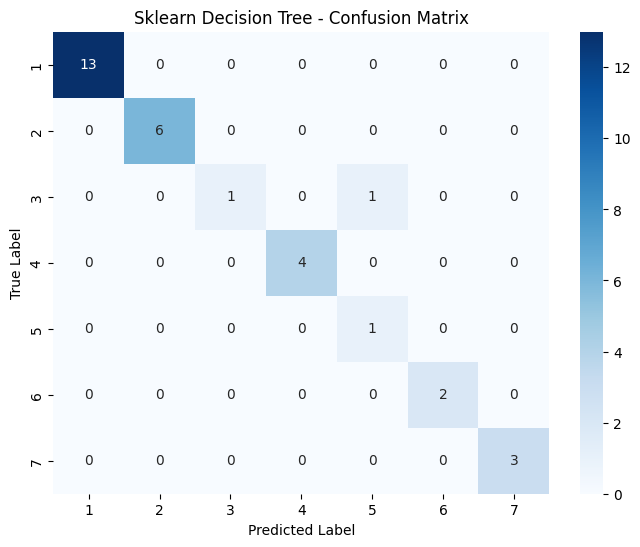


CUSTOM DECISION TREE RESULTS

Confusion Matrix:

[[13  0  0  0  0  0  0]
 [ 0  6  0  0  0  0  0]
 [ 0  0  1  0  1  0  0]
 [ 0  0  0  4  0  0  0]
 [ 0  0  0  0  1  0  0]
 [ 0  0  0  0  0  2  0]
 [ 0  0  0  0  0  0  3]]

Class-wise Accuracy, Precision, Recall:

Class 1:
 Accuracy : 1.0000
 Precision: 1.0000
 Recall   : 1.0000

Class 2:
 Accuracy : 1.0000
 Precision: 1.0000
 Recall   : 1.0000

Class 3:
 Accuracy : 0.9677
 Precision: 1.0000
 Recall   : 0.5000

Class 4:
 Accuracy : 1.0000
 Precision: 1.0000
 Recall   : 1.0000

Class 5:
 Accuracy : 0.9677
 Precision: 0.5000
 Recall   : 1.0000

Class 6:
 Accuracy : 1.0000
 Precision: 1.0000
 Recall   : 1.0000

Class 7:
 Accuracy : 1.0000
 Precision: 1.0000
 Recall   : 1.0000



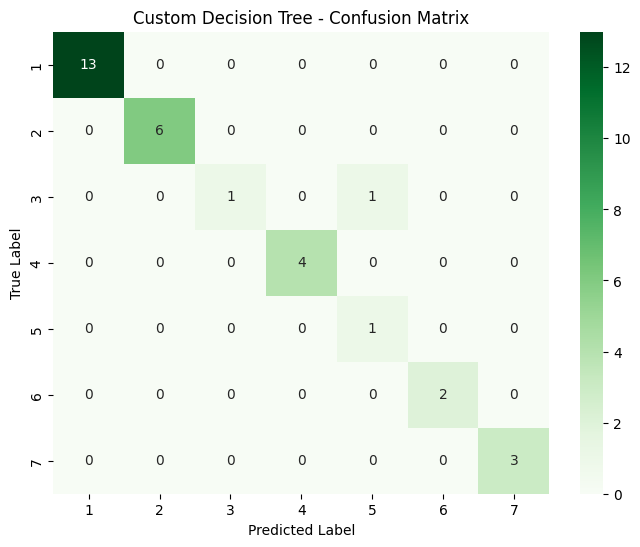

In [4]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# LOAD ZOO DATASET
# ============================================================
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/zoo/zoo.data"

columns = [
    "animal_name", "hair", "feathers", "eggs", "milk", "airborne", "aquatic",
    "predator", "toothed", "backbone", "breathes", "venomous", "fins",
    "legs", "tail", "domestic", "catsize", "class_type"
]

data = pd.read_csv(url, header=None, names=columns)
data = data.drop("animal_name", axis=1)

X = data.drop("class_type", axis=1)
y = data["class_type"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

classes = np.unique(y)

# ============================================================
# PART 1: SKLEARN DECISION TREE
# ============================================================

print("\n==============================")
print("SKLEARN DECISION TREE RESULTS")
print("==============================\n")

clf = DecisionTreeClassifier(criterion="gini", random_state=42)
clf.fit(X_train, y_train)

y_pred_sklearn = clf.predict(X_test)

cm_sklearn = confusion_matrix(y_test, y_pred_sklearn)
print("Confusion Matrix:\n")
print(cm_sklearn)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_sklearn))

# Heatmap - Sklearn
plt.figure(figsize=(8,6))
sns.heatmap(cm_sklearn, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes,
            yticklabels=classes)
plt.title("Sklearn Decision Tree - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# ============================================================
# PART 2: CUSTOM DECISION TREE
# ============================================================

print("\n==============================")
print("CUSTOM DECISION TREE RESULTS")
print("==============================\n")

class DecisionTreeCustom:
    def __init__(self, max_depth=10):
        self.max_depth = max_depth
        self.tree = None

    def gini(self, y):
        counts = Counter(y)
        impurity = 1
        for label in counts:
            prob = counts[label] / len(y)
            impurity -= prob ** 2
        return impurity

    def best_split(self, X, y):
        best_gini = float("inf")
        best_feature = None
        best_value = None

        X = np.array(X)
        y = np.array(y)

        for feature in range(X.shape[1]):
            values = np.unique(X[:, feature])

            for val in values:
                left = y[X[:, feature] <= val]
                right = y[X[:, feature] > val]

                if len(left) == 0 or len(right) == 0:
                    continue

                gini = (len(left)/len(y))*self.gini(left) + \
                       (len(right)/len(y))*self.gini(right)

                if gini < best_gini:
                    best_gini = gini
                    best_feature = feature
                    best_value = val

        return best_feature, best_value

    def build_tree(self, X, y, depth):
        if len(set(y)) == 1 or depth >= self.max_depth:
            return Counter(y).most_common(1)[0][0]

        feature, value = self.best_split(X, y)

        if feature is None:
            return Counter(y).most_common(1)[0][0]

        X = np.array(X)
        y = np.array(y)

        left_mask = X[:, feature] <= value
        right_mask = X[:, feature] > value

        left_tree = self.build_tree(X[left_mask], y[left_mask], depth+1)
        right_tree = self.build_tree(X[right_mask], y[right_mask], depth+1)

        return {"feature": feature,
                "value": value,
                "left": left_tree,
                "right": right_tree}

    def fit(self, X, y):
        self.tree = self.build_tree(X, y, 0)

    def predict_sample(self, x, tree):
        if not isinstance(tree, dict):
            return tree

        if x[tree["feature"]] <= tree["value"]:
            return self.predict_sample(x, tree["left"])
        else:
            return self.predict_sample(x, tree["right"])

    def predict(self, X):
        X = np.array(X)
        return np.array([self.predict_sample(x, self.tree) for x in X])


# Train Custom Tree
custom_tree = DecisionTreeCustom(max_depth=10)
custom_tree.fit(X_train.values, y_train.values)

y_pred_custom = custom_tree.predict(X_test.values)

# Confusion Matrix - Custom
cm_custom = np.zeros((len(classes), len(classes)), dtype=int)

for true, pred in zip(y_test.values, y_pred_custom):
    cm_custom[true-1][pred-1] += 1

print("Confusion Matrix:\n")
print(cm_custom)

# Class-wise Metrics
print("\nClass-wise Accuracy, Precision, Recall:\n")

total = np.sum(cm_custom)

for i in range(len(classes)):
    TP = cm_custom[i,i]
    FN = np.sum(cm_custom[i,:]) - TP
    FP = np.sum(cm_custom[:,i]) - TP
    TN = total - (TP + FP + FN)

    accuracy = (TP + TN) / total
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0

    print(f"Class {i+1}:")
    print(f" Accuracy : {accuracy:.4f}")
    print(f" Precision: {precision:.4f}")
    print(f" Recall   : {recall:.4f}")
    print()

# Heatmap - Custom
plt.figure(figsize=(8,6))
sns.heatmap(cm_custom, annot=True, fmt="d", cmap="Greens",
            xticklabels=classes,
            yticklabels=classes)
plt.title("Custom Decision Tree - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()
